# Sentiment Classification with RoBERTa - SST-5

This project fine-tunes the pretrained `roberta-base` model for five-class sentiment classification using the Stanford Sentiment Treebank (SST-5). The experiment emphasizes a reproducible train/validation/test workflow, validation-based checkpoint selection, class-level evaluation, ordinal sentiment error analysis, confidence analysis, and a separate demonstration of RoBERTa's pretrained masked-language-model capability.

## 1. Import Required Libraries

Import the libraries needed for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducible training.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the SST-5 Dataset

Load the five-class Stanford Sentiment Treebank dataset and inspect its available splits before constructing the modelling splits.

In [2]:
dataset = load_dataset("SetFit/sst5")

print(dataset)

for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} samples")

class_names = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

print("Classes:", class_names)

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})
train: 8544 samples
validation: 1101 samples
test: 2210 samples
Classes: ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']


## 3. Create Stratified Train, Validation, and Test Splits

Keep the original SST-5 test set untouched for final evaluation. Create a stratified validation set from the training data so each sentiment class remains proportionally represented.

In [3]:
train_texts = np.array(dataset["train"]["text"], dtype=object)
train_labels = np.array(dataset["train"]["label"], dtype=np.int64)

test_texts = np.array(dataset["test"]["text"], dtype=object)
test_labels = np.array(dataset["test"]["label"], dtype=np.int64)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

print("\nTraining Distribution:")
print(np.bincount(train_labels, minlength=5))

print("\nValidation Distribution:")
print(np.bincount(val_labels, minlength=5))

print("\nTest Distribution:")
print(np.bincount(test_labels, minlength=5))

Training Samples: 7689
Validation Samples: 855
Test Samples: 2210

Training Distribution:
[ 983 1996 1461 2090 1159]

Validation Distribution:
[109 222 163 232 129]

Test Distribution:
[279 633 389 510 399]


## 4. Explore the Dataset

Inspect class balance and representative sentences to understand the ordinal five-level sentiment structure.

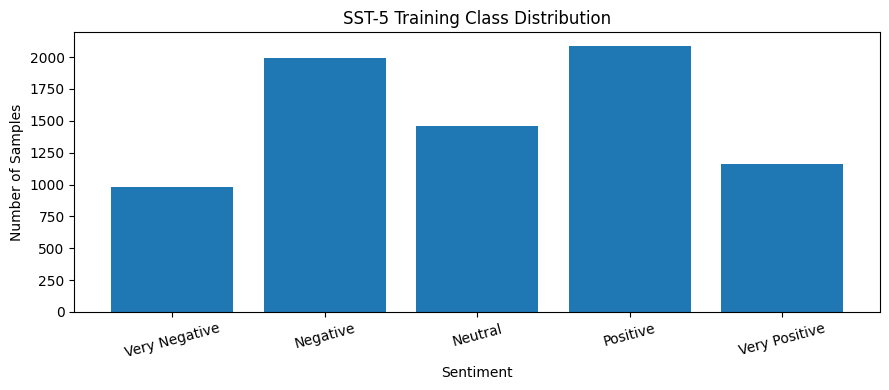

Class: Very Negative
we do n't get paid enough to sit through crap like this .
it is dark , brooding and slow , and takes its central idea way too seriously .

Class: Negative
a moving picture that does not move .
ignore the reputation , and ignore the film .

Class: Neutral
this sort of cute and cloying material is far from zhang 's forte and it shows .
and that should tell you everything you need to know about all the queen 's men .

Class: Positive
this fascinating experiment plays as more of a poetic than a strict reality , creating an intriguing species of artifice that gives the lady and the duke something of a theatrical air .
what lifts the film high above run-of-the-filth gangster flicks is its refusal to recognise any of the signposts , as if discovering a way through to the bitter end without a map .

Class: Very Positive
audiard successfully maintains suspense on different levels throughout a film that is both gripping and compelling .
about schmidt is undoubtedly one of th

In [4]:
train_counts = np.bincount(train_labels, minlength=len(class_names))

plt.figure(figsize=(9, 4))
plt.bar(class_names, train_counts)
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("SST-5 Training Class Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    indices = np.where(train_labels == class_id)[0]
    print("=" * 90)
    print("Class:", class_name)
    for index in indices[:2]:
        print(train_texts[index])
    print()

## 5. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer so the input representation is aligned with the pretrained language model.

In [5]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(model_name)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(
    train_texts[0],
    truncation=True,
    max_length=max_length
)

print("Sample Token Count:", len(sample["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 47


## 6. Tokenize the Dataset

Tokenize each split with truncation while leaving padding to the data collator so batches are dynamically padded.

In [6]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length
    )

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "text": test_texts.tolist(),
    "label": test_labels.tolist()
})

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/7689 [00:00<?, ? examples/s]

Map:   0%|          | 0/855 [00:00<?, ? examples/s]

Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 7689
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 855
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 2210
})


## 7. Build the RoBERTa Classifier

Load pretrained RoBERTa and configure the task-specific output layer for five sentiment classes.

In [7]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={i: name for i, name in enumerate(class_names)},
    label2id={name: i for i, name in enumerate(class_names)}
)

model.config.problem_type = "single_label_classification"

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print("Parameters:", f"{model.num_parameters():,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 5
Parameters: 124,649,477


## 8. Define Evaluation Metrics

Use accuracy together with macro and weighted precision, recall, and F1-score. Macro F1 is useful because the SST-5 classes are not perfectly balanced.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

## 9. Configure Fine-Tuning

Configure a conservative fine-tuning schedule and use validation macro F1 for checkpoint selection.

In [10]:
training_args = TrainingArguments(
    output_dir="./roberta_sst5_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Fine-tuning configuration ready.")

Fine-tuning configuration ready.


## 10. Fine-Tune RoBERTa

Train only on the training split, evaluate on validation data, and restore the checkpoint with the strongest validation macro F1.

In [11]:
train_result = trainer.train()

print("Training completed.")
print("Training Loss:", train_result.training_loss)
print("Best Checkpoint:", trainer.state.best_model_checkpoint)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.577719,1.571979,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827
2,1.571985,1.569257,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827
3,1.571168,1.570107,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Training Loss: 1.5736239215853474
Best Checkpoint: ./roberta_sst5_results/checkpoint-481


## 11. Training Curves

Inspect training loss and validation performance across epochs.

In [ ]:
history = pd.DataFrame(trainer.state.log_history)

train_history = history[history["loss"].notna()].copy()
eval_history = history[history["eval_loss"].notna()].copy()

plt.figure(figsize=(8, 4))
plt.plot(train_history["epoch"], train_history["loss"], marker="o", label="Training Loss")
plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(eval_history["epoch"], eval_history["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(eval_history["epoch"], eval_history["eval_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.show()

best_row = eval_history.loc[eval_history["eval_macro_f1"].idxmax()]

print("Best Epoch:", int(best_row["epoch"]))
print(f"Best Validation Accuracy: {best_row['eval_accuracy']:.4f}")
print(f"Best Validation Macro F1: {best_row['eval_macro_f1']:.4f}")

## 12. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the held-out test set.

In [ ]:
test_output = trainer.predict(test_dataset)

test_predictions = np.argmax(test_output.predictions, axis=-1)

test_accuracy = accuracy_score(test_labels, test_predictions)

test_macro_precision, test_macro_recall, test_macro_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_macro_precision:.4f}")
print(f"Test Macro Recall: {test_macro_recall:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

## 13. Classification Report and Confusion Matrix

Inspect class-level performance and visualize sentiment confusions.

In [ ]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(test_labels, test_predictions)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("Confusion Matrix:")
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SST-5 Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Ordinal Sentiment Error Analysis

Measure how far predictions deviate from the true sentiment level.

In [ ]:
absolute_errors = np.abs(test_labels - test_predictions)

mean_absolute_sentiment_error = np.mean(absolute_errors)
exact_accuracy = np.mean(absolute_errors == 0)
within_one_level = np.mean(absolute_errors <= 1)

print(f"Mean Absolute Sentiment Error: {mean_absolute_sentiment_error:.4f}")
print(f"Exact Sentiment Accuracy: {exact_accuracy:.4f}")
print(f"Within One Sentiment Level: {within_one_level:.4f}")

error_counts = pd.Series(absolute_errors).value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)
plt.xlabel("Absolute Sentiment-Level Error")
plt.ylabel("Number of Test Samples")
plt.title("Ordinal Prediction Error Distribution")
plt.show()

## 15. Confidence Analysis

Compare prediction confidence for correct and incorrect predictions.

In [ ]:
probabilities = torch.softmax(
    torch.tensor(test_output.predictions),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = test_predictions == test_labels

print(
    f"Mean Confidence - Correct: "
    f"{predicted_confidence[correct_mask].mean():.4f}"
)

print(
    f"Mean Confidence - Incorrect: "
    f"{predicted_confidence[~correct_mask].mean():.4f}"
)

plt.figure(figsize=(8, 4))
plt.hist(
    predicted_confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct"
)
plt.hist(
    predicted_confidence[~correct_mask],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)
plt.xlabel("Predicted Class Confidence")
plt.ylabel("Number of Samples")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()

## 16. Representative Error Analysis

Inspect misclassified examples and their top predicted classes.

In [ ]:
misclassified_indices = np.where(test_predictions != test_labels)[0]

print("Misclassified Test Samples:", len(misclassified_indices))

for index in misclassified_indices[:10]:
    probabilities_row = probabilities[index]
    top_indices = np.argsort(probabilities_row)[-3:][::-1]

    print("=" * 100)
    print("Text:", test_texts[index])
    print("True Label:", class_names[test_labels[index]])
    print("Predicted Label:", class_names[test_predictions[index]])
    print("Top Predictions:")

    for class_id in top_indices:
        print(
            f"  {class_names[class_id]}: "
            f"{probabilities_row[class_id]:.4f}"
        )

## 17. Interactive Sentiment Prediction

Use the fine-tuned classifier on custom text.

In [ ]:
def predict_sentiment(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    encoded = {
        key: value.to(model.device)
        for key, value in encoded.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()[0]

    predicted_class = int(np.argmax(probabilities))

    print("Text:", text)
    print("Prediction:", class_names[predicted_class])
    print("Confidence:", f"{probabilities[predicted_class]:.4f}")
    print("\nClass Probabilities:")

    for class_name, probability in zip(class_names, probabilities):
        print(f"{class_name:<15} {probability:.4f}")

## 18. RoBERTa Masked Language Modelling Demonstration

Demonstrate the separate masked-language-model capability of the pretrained RoBERTa model.

In [ ]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model="roberta-base"
)

def suggest_words(text, top_k=5):
    if "<mask>" not in text:
        print("Please include <mask> in your sentence.")
        return

    results = fill_mask(text, top_k=top_k)

    print("Input:", text)
    print("Suggestions:")

    for result in results:
        word = result["token_str"].strip()
        score = result["score"]
        print(f"{word:<20} {score:.4f}")

suggest_words("The movie was <mask>.")
suggest_words("This experience felt <mask> and strange.")

## 19. Key Findings



## 20. Conclusion

